<a href="https://colab.research.google.com/github/TebogoLesedi1/Property_Price_Prediction/blob/main/Property24_price_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data loading and data cleaning**

step 1: lets mount our drive to google colab, its for us to access our notebook and use the files in our drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


step 2.1: lets import a pandas library

In [7]:
import pandas as pd

step 2.2: let pandas read your csv file

In [12]:
data = pd.read_csv("/content/drive/MyDrive/property24.csv")
data.head()

,PROPERTY_ID,COUNTRY,PROVINCE,CITY,PROPERTY_PRICE,BEDROOMS,BATHROOMS,PARKING,FLOOR_SIZE,Monthly_Repayment,Total_Once_off_Costs,Min_Gross_Monthly_Income
0,1,South Africa,Gauteng,Sandton,2542743,1,1,3,176,29801,235009,94255
1,2,South Africa,Western Cape,Sea Point,5154572,4,3,3,125,44365,118772,126685
2,3,South Africa,KwaZulu-Natal,Ballito,1582180,3,3,1,122,11571,212091,166693
3,4,South Africa,Eastern Cape,Gqeberha,3084489,4,2,3,144,12525,145584,183332
4,5,South Africa,Free State,Bloemfontein,1849890,4,2,2,178,20109,291337,60914


Step 3: we need to understand our data first before anything

In [13]:
data.shape #the rows and columns

(100000, 12)

In [14]:
data.columns #columns names

Index(['PROPERTY_ID', 'COUNTRY', 'PROVINCE', 'CITY', 'PROPERTY_PRICE',
       'BEDROOMS', 'BATHROOMS', 'PARKING', 'FLOOR_SIZE', 'Monthly_Repayment',
       'Total_Once_off_Costs', 'Min_Gross_Monthly_Income'],
      dtype='object')

In [15]:
data.info() # the data types including nulls if they exists

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   PROPERTY_ID               100000 non-null  int64 
 1   COUNTRY                   100000 non-null  object
 2   PROVINCE                  100000 non-null  object
 3   CITY                      100000 non-null  object
 4   PROPERTY_PRICE            100000 non-null  int64 
 5   BEDROOMS                  100000 non-null  int64 
 6   BATHROOMS                 100000 non-null  int64 
 7   PARKING                   100000 non-null  int64 
 8   FLOOR_SIZE                100000 non-null  int64 
 9   Monthly_Repayment         100000 non-null  int64 
 10  Total_Once_off_Costs      100000 non-null  int64 
 11  Min_Gross_Monthly_Income  100000 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 9.2+ MB


In [16]:
data.describe() #stats for numerical

,PROPERTY_ID,PROPERTY_PRICE,BEDROOMS,BATHROOMS,PARKING,FLOOR_SIZE,Monthly_Repayment,Total_Once_off_Costs,Min_Gross_Monthly_Income
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2.423381e+06,2.498690,1.998910,2.001610,149.586780,30506.910010,199984.712120,109917.970890
std,28867.657797,1.234770e+06,1.118861,0.815571,0.817811,52.060397,13000.168559,86771.522081,46105.585563
min,1.000000,8.500370e+05,1.000000,1.000000,1.000000,60.000000,8000.000000,50002.000000,30003.000000
25%,25000.750000,1.519829e+06,1.000000,1.000000,1.000000,104.000000,19262.750000,124757.500000,70081.500000
50%,50000.500000,2.192644e+06,2.000000,2.000000,2.000000,150.000000,30449.500000,199638.000000,109802.500000
75%,75000.250000,2.924208e+06,4.000000,3.000000,3.000000,195.000000,41770.250000,275608.500000,149718.250000
max,100000.000000,7.349562e+06,4.000000,3.000000,3.000000,239.000000,52999.000000,349999.000000,189997.000000


Step 4: we check for duplicates in the data

In [17]:
data.duplicated().sum()

np.int64(0)

there was zero duplicates
Step 5:  let's check for missing (null values) data

In [18]:
data.isnull().sum()

,0
PROPERTY_ID,0
COUNTRY,0
PROVINCE,0
CITY,0
PROPERTY_PRICE,0
BEDROOMS,0
BATHROOMS,0
PARKING,0
FLOOR_SIZE,0
Monthly_Repayment,0


there is no missing data/ null values Step 6: lets fix data types

In [19]:
data.dtypes

,0
PROPERTY_ID,int64
COUNTRY,object
PROVINCE,object
CITY,object
PROPERTY_PRICE,int64
BEDROOMS,int64
BATHROOMS,int64
PARKING,int64
FLOOR_SIZE,int64
Monthly_Repayment,int64


step 7: lets convert whole numbers(int) to  decimals

In [29]:
data['PROPERTY_PRICE'] = data['PROPERTY_PRICE'].astype(float)


In [22]:
data['Total_Once_off_Costs'] = data['Total_Once_off_Costs'].astype(float)


In [23]:
data['Min_Gross_Monthly_Income'] = data['Min_Gross_Monthly_Income'].astype(float)

In [24]:
data['Monthly_Repayment'] = data['Monthly_Repayment'].astype(float)

In [25]:
data['FLOOR_SIZE'] = data['FLOOR_SIZE'].astype(float)

In [27]:
data.head() # lets see if the data types have changed

,PROPERTY_ID,COUNTRY,PROVINCE,CITY,PROPERTY_PRICE,BEDROOMS,BATHROOMS,PARKING,FLOOR_SIZE,Monthly_Repayment,Total_Once_off_Costs,Min_Gross_Monthly_Income
0,1,South Africa,Gauteng,Sandton,2542743.0,1,1,3,176.0,29801.0,235009.0,94255.0
1,2,South Africa,Western Cape,Sea Point,5154572.0,4,3,3,125.0,44365.0,118772.0,126685.0
2,3,South Africa,KwaZulu-Natal,Ballito,1582180.0,3,3,1,122.0,11571.0,212091.0,166693.0
3,4,South Africa,Eastern Cape,Gqeberha,3084489.0,4,2,3,144.0,12525.0,145584.0,183332.0
4,5,South Africa,Free State,Bloemfontein,1849890.0,4,2,2,178.0,20109.0,291337.0,60914.0


step 8: we are now  looking for outliers

In [30]:
data['PROPERTY_PRICE'].describe()

,PROPERTY_PRICE
count,1.000000e+05
mean,2.423381e+06
std,1.234770e+06
min,8.500370e+05
25%,1.519829e+06
50%,2.192644e+06
75%,2.924208e+06
max,7.349562e+06


we are removing outliers using the IQR  method

In [31]:
Q1 = data['PROPERTY_PRICE'].quantile(0.25)
Q3 = data['PROPERTY_PRICE'].quantile(0.75)
IQR = Q3 - Q1

data = data[(data['PROPERTY_PRICE'] >= Q1 - 1.5*IQR) & (data['PROPERTY_PRICE'] <= Q3 + 1.5*IQR)]

step 9: Feature Engineering, lets create  new useful coulmns

In [32]:
data ['price_per_m2'] = data['PROPERTY_PRICE'] / data['FLOOR_SIZE']

/tmp/ipykernel_49016/2148900454.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data ['price_per_m2'] = data['PROPERTY_PRICE'] / data['FLOOR_SIZE']


lets check if the new coulmn is add

In [35]:
data.info() # lets if the new coulnm has been created

<class 'pandas.core.frame.DataFrame'>
Index: 95249 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PROPERTY_ID               95249 non-null  int64  
 1   COUNTRY                   95249 non-null  object 
 2   PROVINCE                  95249 non-null  object 
 3   CITY                      95249 non-null  object 
 4   PROPERTY_PRICE            95249 non-null  float64
 5   BEDROOMS                  95249 non-null  int64  
 6   BATHROOMS                 95249 non-null  int64  
 7   PARKING                   95249 non-null  int64  
 8   FLOOR_SIZE                95249 non-null  float64
 9   Monthly_Repayment         95249 non-null  float64
 10  Total_Once_off_Costs      95249 non-null  float64
 11  Min_Gross_Monthly_Income  95249 non-null  float64
 12  price_per_m2              95249 non-null  float64
dtypes: float64(6), int64(4), object(3)
memory usage: 10.2+ MB


**EDA (Exploratory Data Analysis)**

lets see which relationships exists bewteen the coulmns

lets import seaborn and matplotlib

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation Matrix, lets see which feature has a strong affect on the price

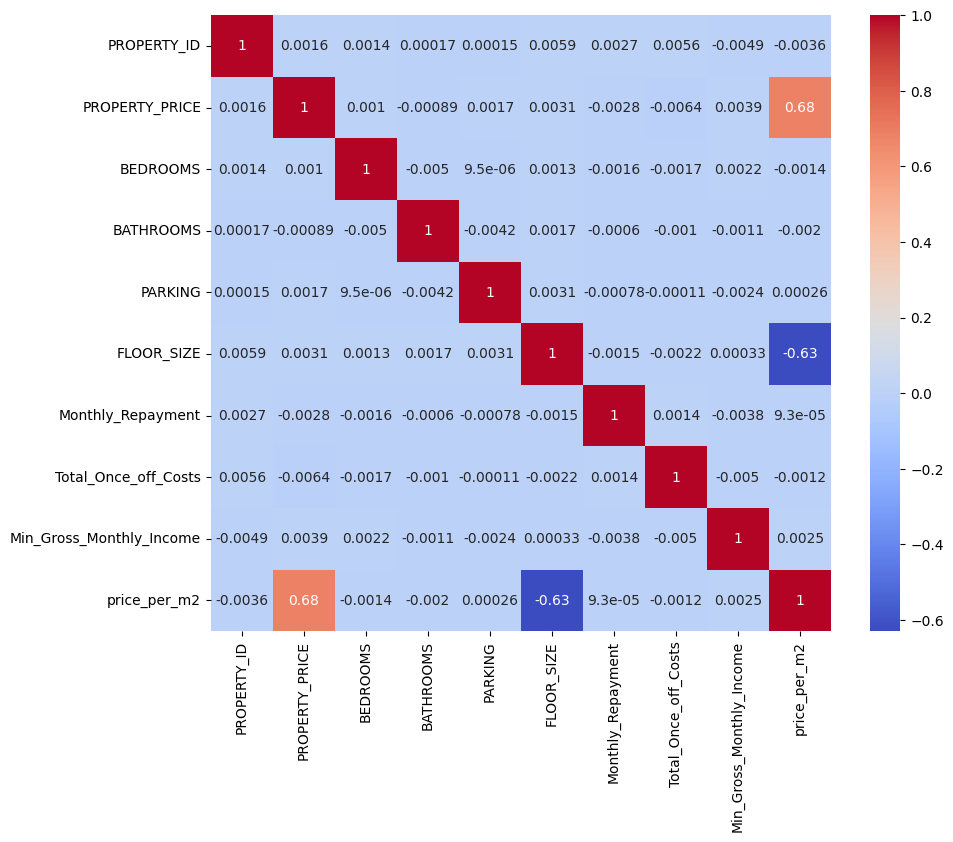

In [40]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

The correlation heatmap shows that property price has the strongest positive relationship with price per square meter (0.68), meaning higher price per m² leads to higher property prices. Floor size has a strong negative relationship with price per m² (-0.63), indicating larger properties tend to have lower cost per square meter. Other variables like bedrooms, bathrooms, and parking show weak correlations with price and may have limited predictive value on their own.

scatterplot

<Axes: xlabel='PROPERTY_PRICE', ylabel='price_per_m2'>

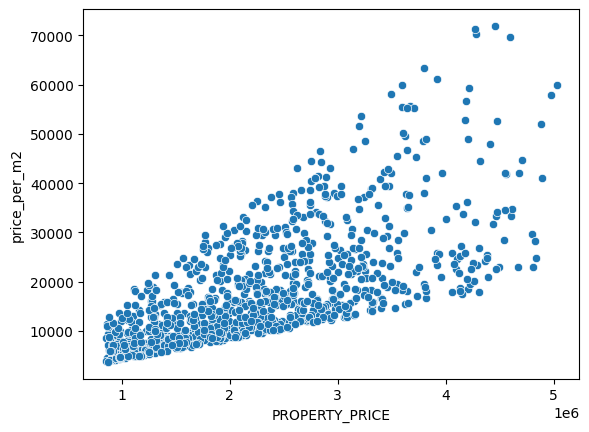

In [44]:
sample_data = data.sample(n=1000, random_state=42)

sns.scatterplot(x='PROPERTY_PRICE', y='price_per_m2', data=sample_data)

the scatterplot shows an increase in size as the increase in price

**THE PRICE PREDICTION MODEL**

lets select features(X) and target(Y)

In [45]:
x = data[['FLOOR_SIZE', 'Monthly_Repayment','Total_Once_off_Costs','Min_Gross_Monthly_Income']]
y = data['PROPERTY_PRICE']

Train-test split, so 80% is training data then the rest 20% test data

In [47]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x ,y, test_size=0.2, random_state=42)

lets training the 1st model, linear regression

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

lets try make predictions

In [49]:
y_pred = model.predict(x_test)


lets evaluate our model

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 910735390826.0256
Mean Absolute Error: 768130.215031546


visualize predictions

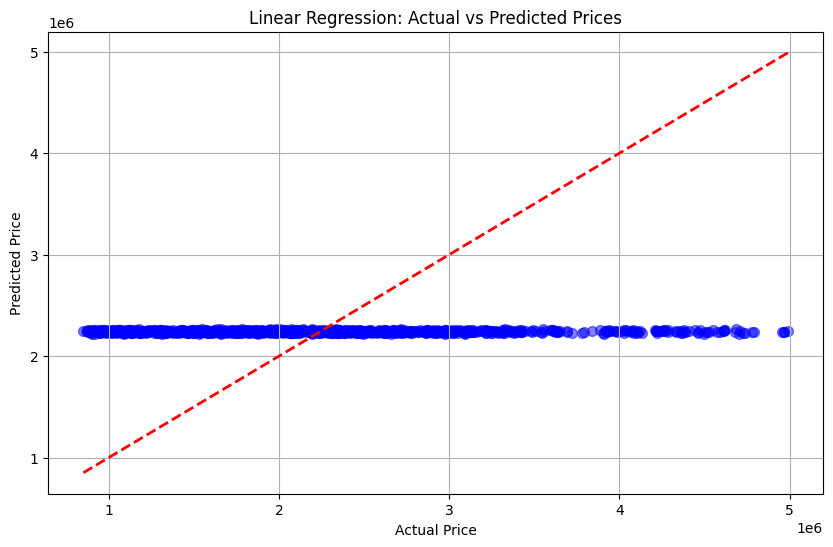

In [66]:
results_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

sample_lr = results_lr.sample(n=min(1000, len(results_lr)), random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(sample_lr['Actual'], sample_lr['Predicted'], color='blue', alpha=0.5, s=50)
plt.plot([sample_lr['Actual'].min(), sample_lr['Actual'].max()],
         [sample_lr['Actual'].min(), sample_lr['Actual'].max()],
         color='red', linestyle='--', linewidth=2)  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.grid(True)
plt.show()

lets improve our model by using different machine learning models

lets train the 2nd model, Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

lets evaluate the models performance

In [58]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest - Mean Absolute Error: {mae_rf}")
print(f"Random Forest - Mean Squared Error: {mse_rf}")

Random Forest - Mean Absolute Error: 792444.0530661417
Random Forest - Mean Squared Error: 965201824046.2324


lets visualize our model

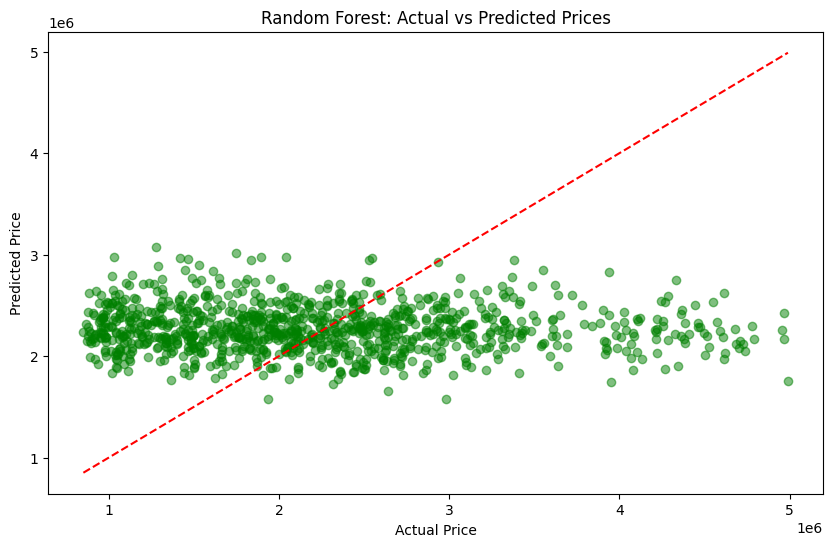

In [60]:
results_rf = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})
sample_rf = results_rf.sample(n=min(1000, len(results_rf)), random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(sample_rf['Actual'], sample_rf['Predicted'], alpha=0.5, color='green')
plt.plot([sample_rf['Actual'].min(), sample_rf['Actual'].max()],
         [sample_rf['Actual'].min(), sample_rf['Actual'].max()],
         color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.show()

lets train our 3rd model, XGBOOST

In [54]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=4)
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

lets evaluate the models performance

In [59]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print(f"XGBoost - Mean Absolute Error: {mae_xgb}")
print(f"XGBoost - Mean Squared Error: {mse_xgb}")

XGBoost - Mean Absolute Error: 779841.849448819
XGBoost - Mean Squared Error: 940411398254.9777


lets visualize this predictions from this model

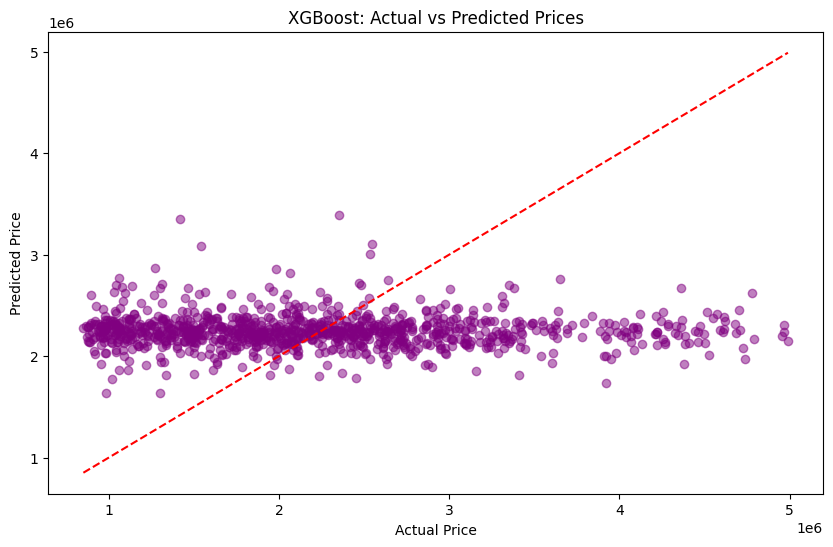

In [61]:
results_xgb = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_xgb})
sample_xgb = results_xgb.sample(n=min(1000, len(results_xgb)), random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(sample_xgb['Actual'], sample_xgb['Predicted'], alpha=0.5, color='purple')
plt.plot([sample_xgb['Actual'].min(), sample_xgb['Actual'].max()],
         [sample_xgb['Actual'].min(), sample_xgb['Actual'].max()],
         color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Prices")
plt.show()

Based on this metrics:
XGBoost - Mean Absolute Error: 779841.849448819
XGBoost - Mean Squared Error:9404113982549777                                                          Random Forest - Mean Absolute Error: 792444.0530661417
Random Forest - Mean Squared Error: 965201824046.2324
Mean Squared Error: 910735390826.0256
Mean Absolute Error: 768130.215031546

the mean (linear regression model )is the most effective for predicting property price. it has achieved low mean erorrs in both metrics

lets save our model

In [67]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/price_model.pkl')

['/content/drive/MyDrive/price_model.pkl']